Saving Sales target.csv to Sales target.csv
First 5 rows:
  Month of Order Date   Category   Target
0              Apr-18  Furniture  10400.0
1              May-18  Furniture  10500.0
2              Jun-18  Furniture  10600.0
3              Jul-18  Furniture  10800.0
4              Aug-18  Furniture  10900.0

Dataset Shape: (36, 3)

Columns:
['Month of Order Date', 'Category', 'Target']

Training Samples: 28
Testing Samples: 8


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network trained successfully!

Neural Network Performance
--------------------------------
Mean Absolute Error : 11720.49
Root Mean Square Error : 12053.12
R2 Score : -17.4846


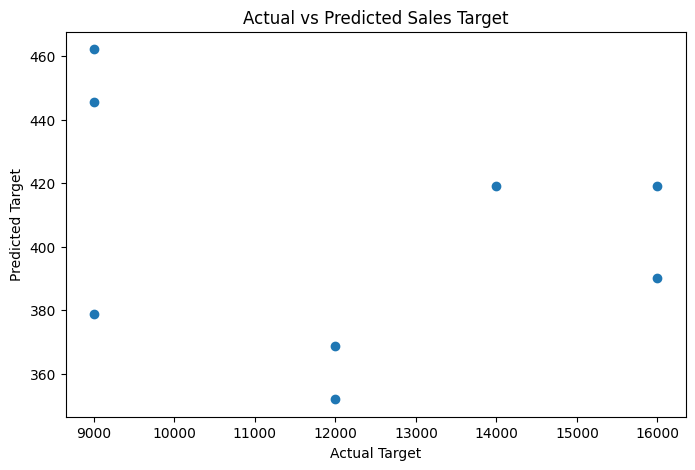

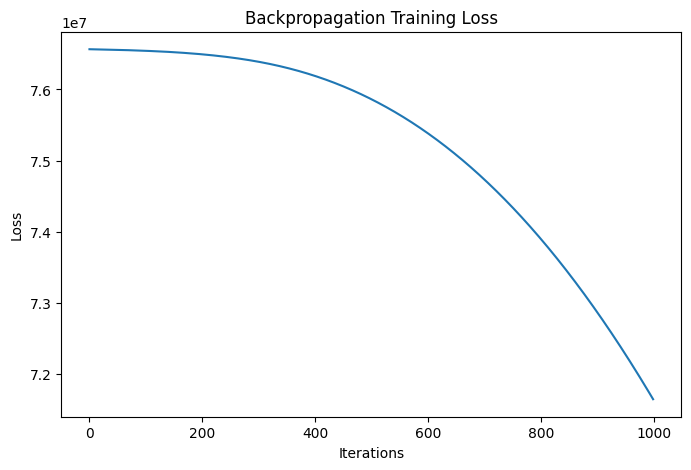

In [3]:
# PRACTICAL 2: FEED FORWARD BACKPROPAGATION
# Dataset: Sales target.csv

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Sales target.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# 2. Convert Month into Numerical Features

df["Month"] = pd.to_datetime(
    df["Month of Order Date"],
    format="%b-%y"
)

df["Month_Number"] = df["Month"].dt.month
df["Year"] = df["Month"].dt.year

# 3. Select Features and Target

X = df[["Month_Number", "Year", "Category"]]
y = df["Target"]

# 4. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "category",
            OneHotEncoder(handle_unknown="ignore"),
            ["Category"]
        ),
        (
            "numeric",
            StandardScaler(),
            ["Month_Number", "Year"]
        )
    ]
)

X_processed = preprocessor.fit_transform(X)

# 5. Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# 6. Create Feed Forward Neural Network

nn_model = MLPRegressor(
    hidden_layer_sizes=(10, 5),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

# 7. Train using Backpropagation

nn_model.fit(X_train, y_train)

print("\nNeural Network trained successfully!")

# 8. Prediction

y_pred = nn_model.predict(X_test)

# 9. Evaluate Model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Performance")
print("--------------------------------")
print("Mean Absolute Error :", round(mae, 2))
print("Root Mean Square Error :", round(rmse, 2))
print("R2 Score :", round(r2, 4))

# 10. Actual vs Predicted Plot

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Sales Target")
plt.show()

# 11. Training Loss Plot

plt.figure(figsize=(8, 5))
plt.plot(nn_model.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Backpropagation Training Loss")
plt.show()